# AI Document Classification and Search
A machine learning and NLP project that classifies news articles into World, Sports, Business, and Science/Technology categories and provides document search using TF-IDF and cosine similarity.
## 1. Load and Explore Dataset

In [4]:
import pandas as pd


In [5]:
df = pd.read_csv("data/train.csv")

In [6]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [7]:
df.shape

(120000, 3)

In [8]:
df.columns


Index(['Class Index', 'Title', 'Description'], dtype='str')

In [9]:
df['Class Index'].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [10]:
df.isnull().sum()


Class Index    0
Title          0
Description    0
dtype: int64

## 2. Data Preprocessing

In [11]:
df["Text"] = df["Title"] + " " + df["Description"]

In [12]:
df[["Class Index", "Text"]].head()

,Class Index,Text
0,3,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new..."


## 3. Train-Test Split

In [13]:
x = df["Text"]
y = df["Class Index"]

In [14]:
from sklearn.model_selection import train_test_split


In [15]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
print(X_train.shape)
print(X_test.shape)

(96000,)
(24000,)


## 4. TF-IDF Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
vectorizer = TfidfVectorizer(max_features=50000)

In [19]:
X_train_vectors = vectorizer.fit_transform(X_train)

In [20]:
X_test_vectors = vectorizer.transform(X_test)

In [21]:
print(X_train_vectors.shape)
print(X_test_vectors.shape)

(96000, 50000)
(24000, 50000)


## 5. Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
model = LogisticRegression(max_iter=1000)

In [24]:
model.fit(X_train_vectors, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## 6. Model Evaluation

In [25]:
predictions = model.predict(X_test_vectors)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9181666666666667


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.93      0.90      0.92      6000
           2       0.95      0.98      0.97      6000
           3       0.90      0.89      0.89      6000
           4       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



In [28]:
new_article = [
    "Apple announced a new artificial intelligence processor for its computers."
]

new_vector = vectorizer.transform(new_article)

prediction = model.predict(new_vector)

print(prediction)

[4]


## 7. Classify New Articles

In [29]:
class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Science/Technology"
}

In [30]:
def classify_article(text):
    text_vector = vectorizer.transform([text])
    prediction = model.predict(text_vector)[0]
    return class_names[prediction]


In [31]:
print(classify_article(
    "The football team won the championship after scoring three goals."
))

print(classify_article(
    "Stock markets rose after the company reported strong quarterly earnings."
))

print(classify_article(
    "Apple announced a new artificial intelligence processor."
))

Sports
Business
Science/Technology


## 8. Document Search with Cosine Similarity

In [32]:
all_vectors = vectorizer.transform(df["Text"])


In [33]:
print(all_vectors.shape)

(120000, 50000)


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

In [35]:
def search_documents(query, top_n=5):
    query_vector = vectorizer.transform([query])

    similarities = cosine_similarity(
        query_vector,
        all_vectors
    ).flatten()

    top_indexes = similarities.argsort()[-top_n:][::-1]

    results = df.iloc[top_indexes].copy()
    results["Similarity"] = similarities[top_indexes]

    return results[["Title", "Description", "Similarity"]]

In [36]:
search_documents("artificial intelligence")

,Title,Description,Similarity
553,NASA Develops Robust Artificial Intelligence f...,NASA is planning to add a strong dose of artif...,0.474367
22402,Artificial heart maker seeking OK to sell device,"After 22 years of experimentation, the maker o...",0.384656
103158,Artificial trees grow on Americans,More and more Americans are waking up Christma...,0.379058
87264,UEFA approves use of artificial turf,The governing body of European soccer has appr...,0.362027
87033,UEFA Approve Use of Artificial Pitches Next Se...,VIENNA (Reuters) - UEFA have approved plans f...,0.353864


## 9. Performance Visualization

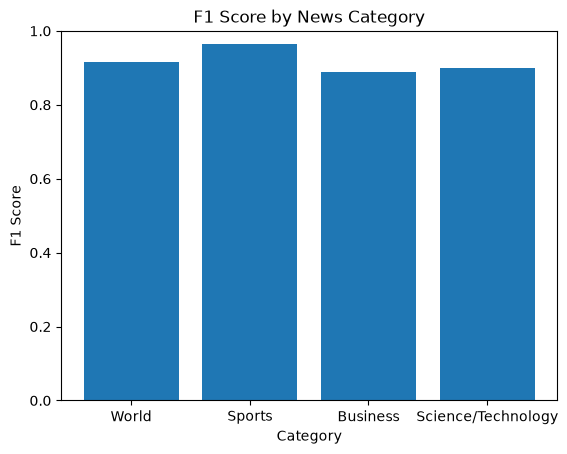

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

f1_scores = f1_score(
    y_test,
    predictions,
    average=None
)

categories = [
    "World",
    "Sports",
    "Business",
    "Science/Technology"
]

plt.bar(categories, f1_scores)

plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.title("F1 Score by News Category")

plt.ylim(0, 1)

plt.show()

## 10. Error Analysis

In [38]:
wrong_predictions = X_test[predictions != y_test]

actual_labels = y_test[predictions != y_test]
predicted_labels = predictions[predictions != y_test]

mistakes = pd.DataFrame({
    "Article": wrong_predictions,
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

mistakes.head(10)

,Article,Actual,Predicted
6638,Olympians pursuit of marketing gold begins lon...,3,2
3996,New Device: Flying Robot Seiko Epson hopes the...,3,4
32672,Terror Plot At Michigan High School A seventee...,4,1
34177,Nextel Wants Better FCC Deal Nextel Communicat...,4,3
52295,Intel puts its weight behind Symbian Intel is ...,3,4
6568,U.S. Rolls Into Softball Gold-Medal Game ATHEN...,1,2
35525,Dial 4-1-1 for Cell Phone Numbers? WASHINGTON-...,3,4
30429,Stakes high for England England will have a se...,1,2
83063,Military Snipers Learn From Competition (AP) A...,2,1
5738,Google Sets Possible Precedent for Future IPOs...,4,3


In [39]:
predictions != y_test

112486    False
109163    False
6638       True
3996       True
39522     False
          ...  
105468    False
90241     False
17201     False
70437     False
28320     False
Name: Class Index, Length: 24000, dtype: bool

In [40]:
wrong_predictions = X_test[predictions != y_test]
actual_labels = y_test[predictions != y_test]
predicted_labels = predictions[predictions != y_test]

mistakes = pd.DataFrame({
    "Article": wrong_predictions,
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

mistakes.head(10)

,Article,Actual,Predicted
6638,Olympians pursuit of marketing gold begins lon...,3,2
3996,New Device: Flying Robot Seiko Epson hopes the...,3,4
32672,Terror Plot At Michigan High School A seventee...,4,1
34177,Nextel Wants Better FCC Deal Nextel Communicat...,4,3
52295,Intel puts its weight behind Symbian Intel is ...,3,4
6568,U.S. Rolls Into Softball Gold-Medal Game ATHEN...,1,2
35525,Dial 4-1-1 for Cell Phone Numbers? WASHINGTON-...,3,4
30429,Stakes high for England England will have a se...,1,2
83063,Military Snipers Learn From Competition (AP) A...,2,1
5738,Google Sets Possible Precedent for Future IPOs...,4,3
